In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

df = pd.read_parquet("../classify_data.parquet").reset_index()
class_map = {
    '0': 0,
    '1-3': 1,
    '4-7': 2,
    '8-14': 3,
    '15-30': 4,
    '31-60': 5
}
df['resolution_class_int'] = df['resolution_class'].map(class_map)

feature_columns = ['Agency','Complaint Type','Descriptor','Location Type', 'Incident Zip', 'City', 'Borough',
                    'Open Data Channel Type', 'Latitude', 'Longitude',
                    'hour_of_day', 'day_of_week', 'month',
                    'is_weekend', 'open_requests_past_24h']

X = df[feature_columns]
y = df['resolution_class_int']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix
)

y_pred_r_forest_20 = np.load("../results/random_forest_predictions_20.npy")
y_pred_r_forest_50 = np.load("../results/random_forest_predictions_50.npy")
y_pred_r_forest_100 = np.load("../results/random_forest_predictions_100.npy")
y_pred_r_forest_150 = np.load("../results/random_forest_predictions_150.npy")
y_prob_r_forest_150 = np.load("../results/random_forest_prob_150.npy")
y_pred_r_forest_250 = np.load("../results/random_forest_predictions_250.npy")
y_pred_logistics = np.load("../results/regresssion_predictions.npy")
y_prob_logistics = np.load("../results/regresssion_prob.npy")
y_pred_nn = np.load("../results/neural_network.npy")
y_prob_nn = np.load("../results/neural_network_prob.npy")

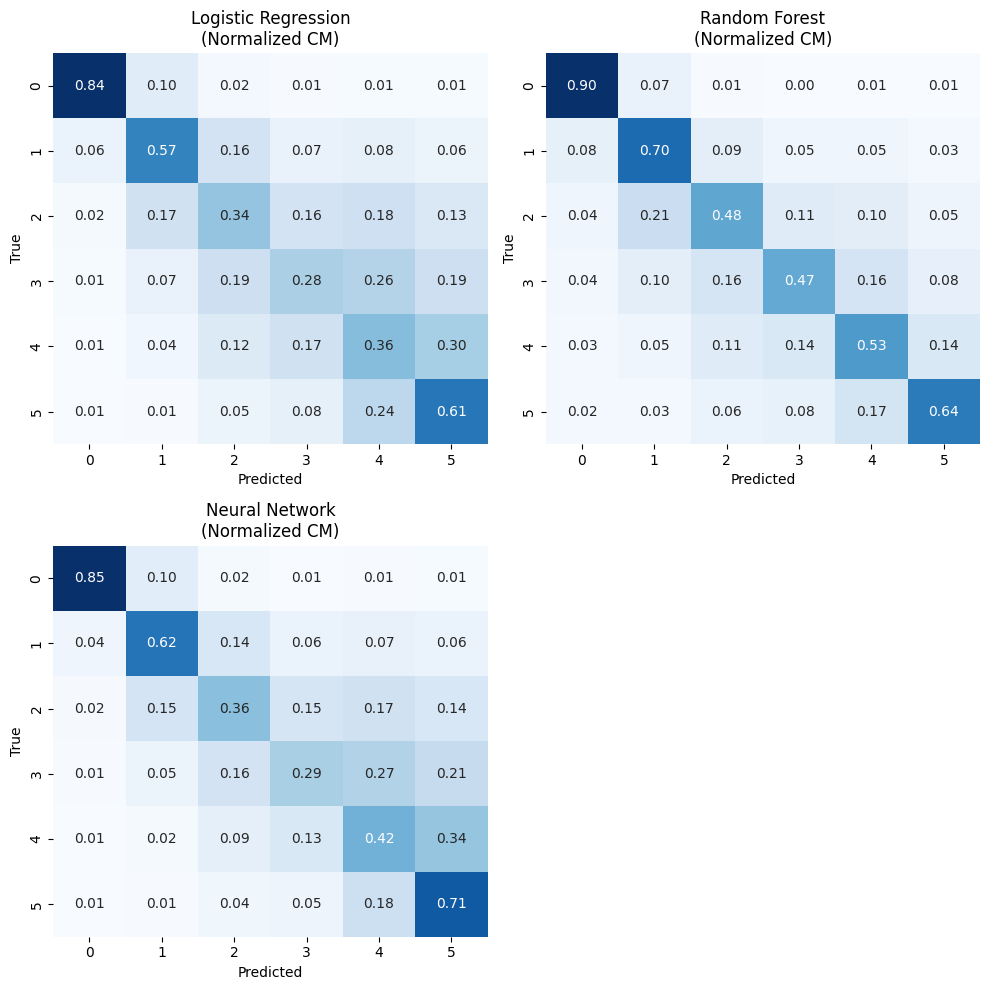

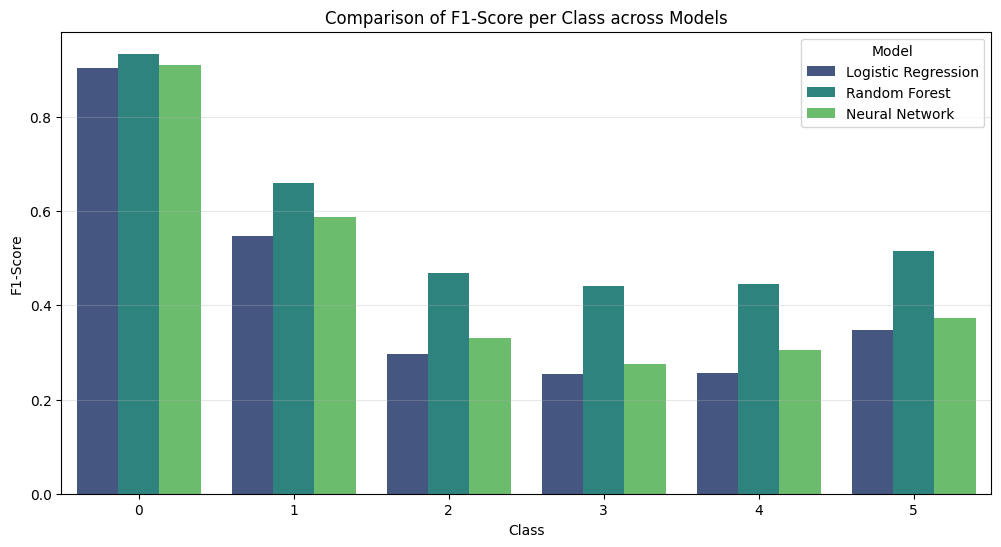

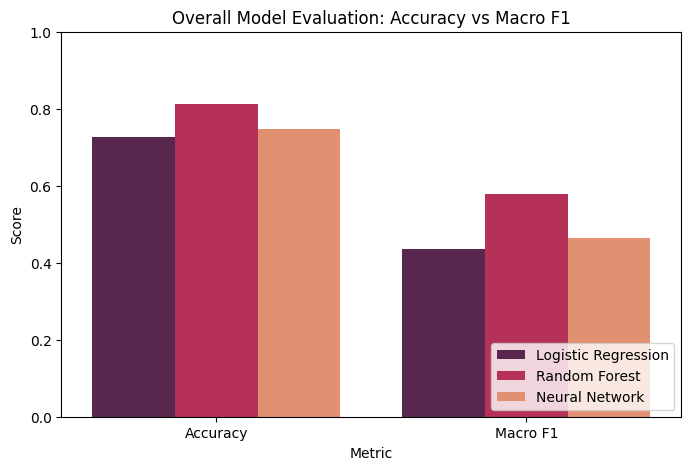

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support

# -----------------------------------------------------------
# 1. SETUP: Organize your data here
# -----------------------------------------------------------
# Assuming you have y_test and prediction arrays for each model
# Example: y_test = [0, 1, 0, ...], y_pred_lr = [0, 1, 1, ...]

# dictionary of your model names and their prediction arrays
model_preds = {
    'Logistic Regression': y_pred_logistics, # Replace with your actual variable
    'Random Forest': y_pred_r_forest_150,       # Replace with your actual variable
    'Neural Network': y_pred_nn       # Replace with your actual variable
}

# List of class names (optional, for better labeling)
class_names = [0, 1, 2, 3, 4, 5] 

# -----------------------------------------------------------
# 2. GRAPH: Normalized Confusion Matrices (Side-by-Side)
# -----------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Flatten axes array for easy indexing
axes = axes.flatten()

for ax, (model_name, preds) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues', cbar=False,
        xticklabels=class_names, yticklabels=class_names, ax=ax
    )

    ax.set_title(f'{model_name}\n(Normalized CM)')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

# If you have fewer models than axes, hide remaining subplots
for unused_ax in axes[len(model_preds):]:
    unused_ax.set_visible(False)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# 3. GRAPH: Per-Class Performance Comparison (Bar Chart)
# -----------------------------------------------------------
# We extract metrics for every class for every model to compare them directly
records = []
for model_name, preds in model_preds.items():
    report = classification_report(y_test, preds, output_dict=True)
    for cls in [str(c) for c in class_names]:
        # You can change 'f1-score' to 'recall' or 'precision' depending on need
        records.append({
            'Model': model_name,
            'Class': cls,
            'F1-Score': report[cls]['f1-score']
        })

df_class = pd.DataFrame(records)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_class, x='Class', y='F1-Score', hue='Model', palette='viridis')
plt.title('Comparison of F1-Score per Class across Models')
plt.grid(axis='y', alpha=0.3)
plt.show()

# -----------------------------------------------------------
# 4. GRAPH: Overall Performance (Macro vs Weighted)
# -----------------------------------------------------------
overall_data = []
for model_name, preds in model_preds.items():
    # Calculate various metrics
    acc = accuracy_score(y_test, preds)
    p, r, macro_f1, _ = precision_recall_fscore_support(y_test, preds, average='macro')
    
    overall_data.append({'Model': model_name, 'Metric': 'Accuracy', 'Score': acc})
    overall_data.append({'Model': model_name, 'Metric': 'Macro F1', 'Score': macro_f1})

df_overall = pd.DataFrame(overall_data)

plt.figure(figsize=(8, 5))
sns.barplot(data=df_overall, x='Metric', y='Score', hue='Model', palette='rocket')
plt.title('Overall Model Evaluation: Accuracy vs Macro F1')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()

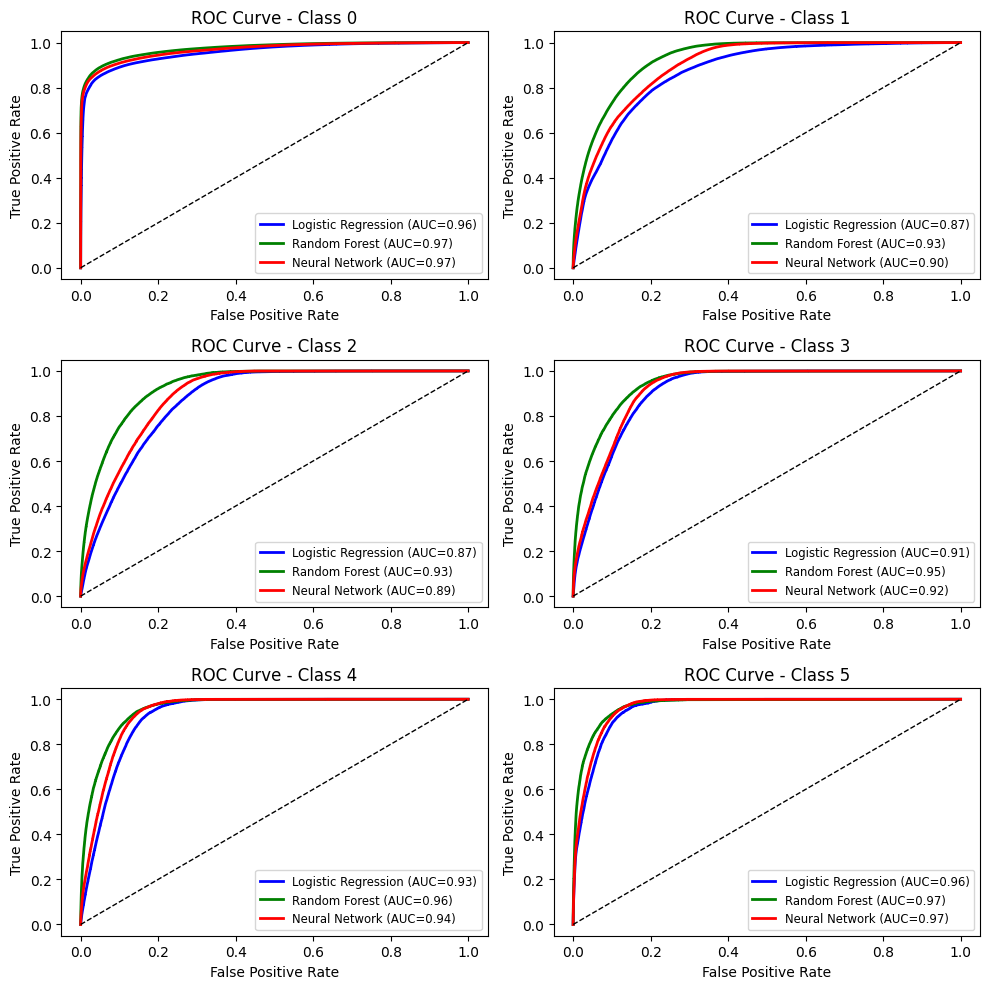

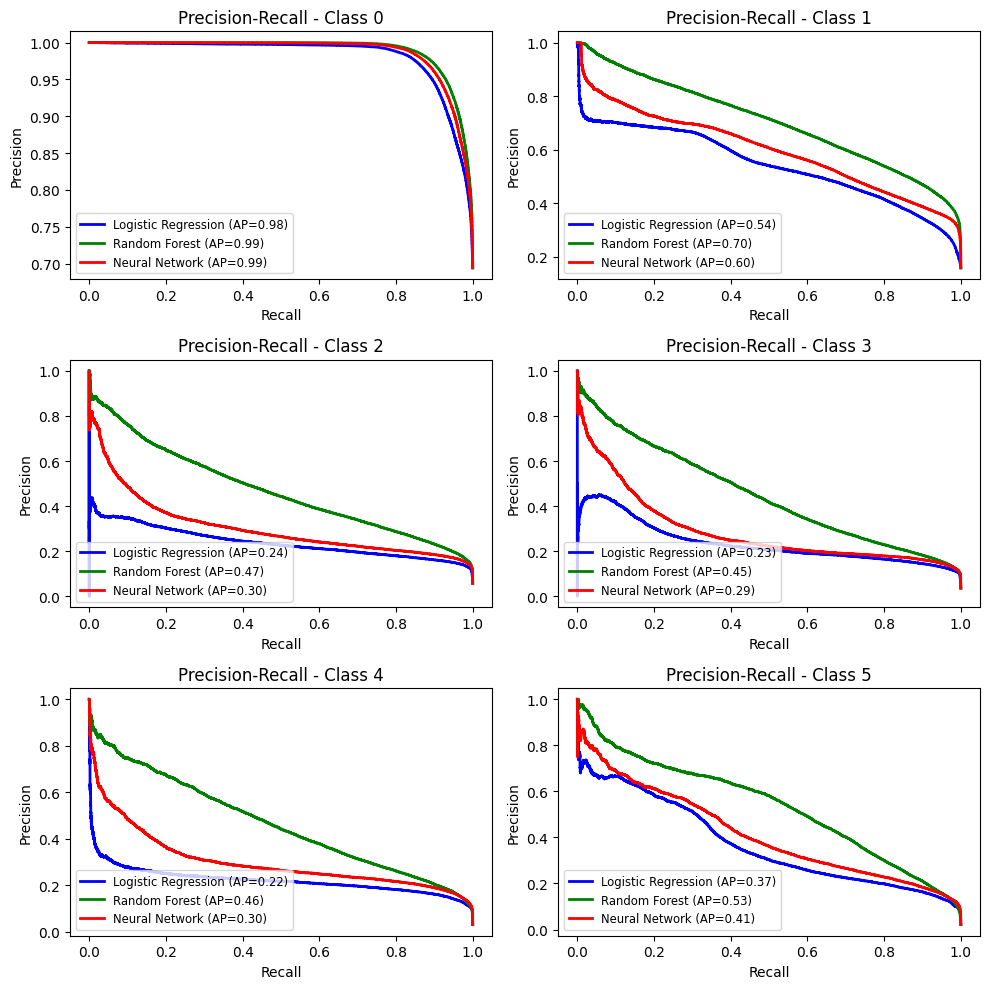

<Figure size 640x480 with 0 Axes>

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

# -----------------------------------------------------------
# 1. SETUP: Prepare Data
# -----------------------------------------------------------
# You need y_test and the PROBABILITIES from each model.
# Example: y_probs_lr = model_lr.predict_proba(X_test)
# y_probs_lr should be shape (n_samples, 6)

# Dictionary of model names and their PROBABILITY arrays
model_probs = {
    'Logistic Regression': y_prob_logistics, 
    'Random Forest': y_prob_r_forest_150,       
    'Neural Network': y_prob_nn       
}

classes = [0, 1, 2, 3, 4, 5]
n_classes = len(classes)

# Binarize y_test for ROC/PR calculations (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=classes)

# Colors for consistency
colors = {'Logistic Regression': 'blue', 'Random Forest': 'green', 'Neural Network': 'red'}

# -----------------------------------------------------------
# 2. GRAPH: ROC-AUC Curves (Grid of 6)
# -----------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.ravel() # Flatten to 1D array for easy looping

for i, cls in enumerate(classes):
    ax = axes[i]
    for model_name, y_score in model_probs.items():
        # Calculate ROC for this specific class vs all others
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        
        ax.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC={roc_auc:.2f})', color=colors[model_name])
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1) # Diagonal random line
    ax.set_title(f'ROC Curve - Class {cls}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc="lower right", fontsize='small')

plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# 3. GRAPH: Precision-Recall Curves (Grid of 6)
# -----------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.ravel()

for i, cls in enumerate(classes):
    ax = axes[i]
    for model_name, y_score in model_probs.items():
        # Calculate PR for this specific class
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        avg_prec = average_precision_score(y_test_bin[:, i], y_score[:, i])
        
        ax.plot(recall, precision, lw=2, label=f'{model_name} (AP={avg_prec:.2f})', color=colors[model_name])
    
    ax.set_title(f'Precision-Recall - Class {cls}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(loc="lower left", fontsize='small')

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

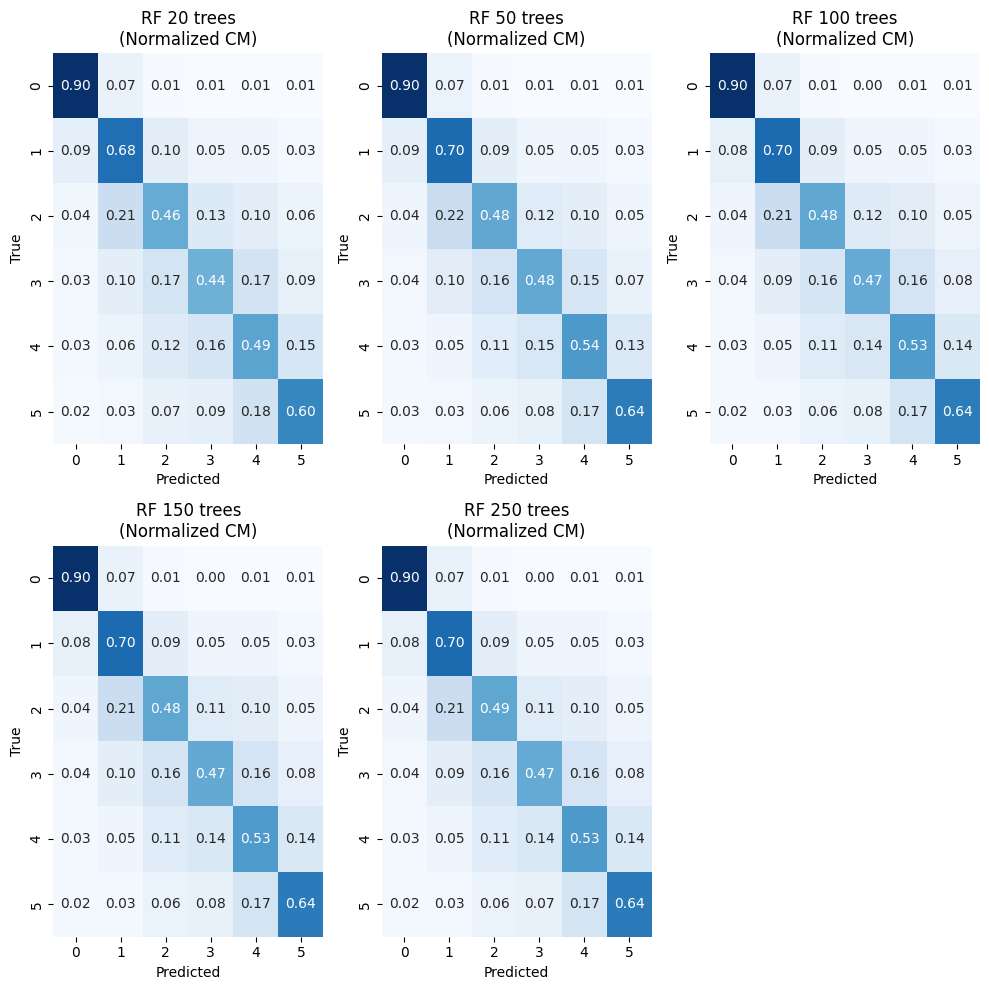

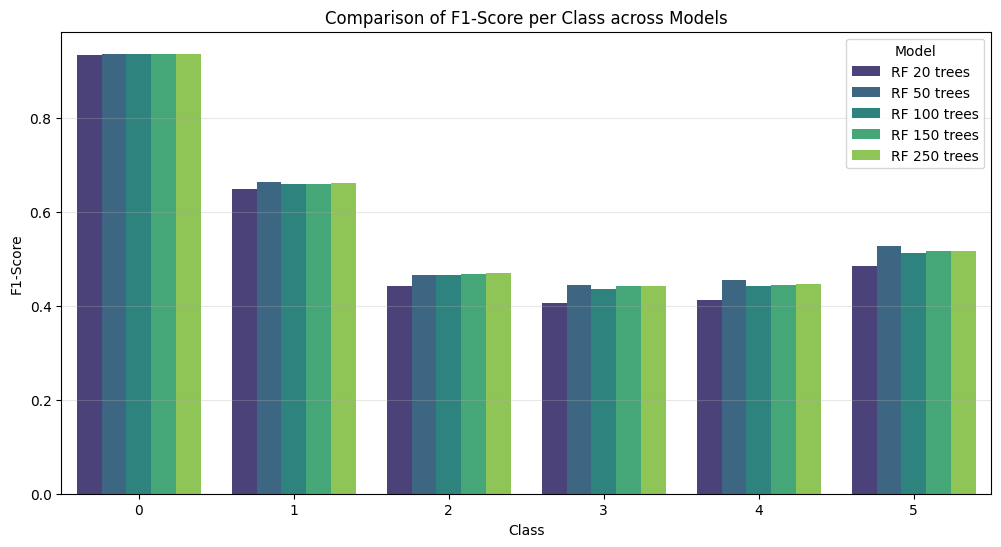

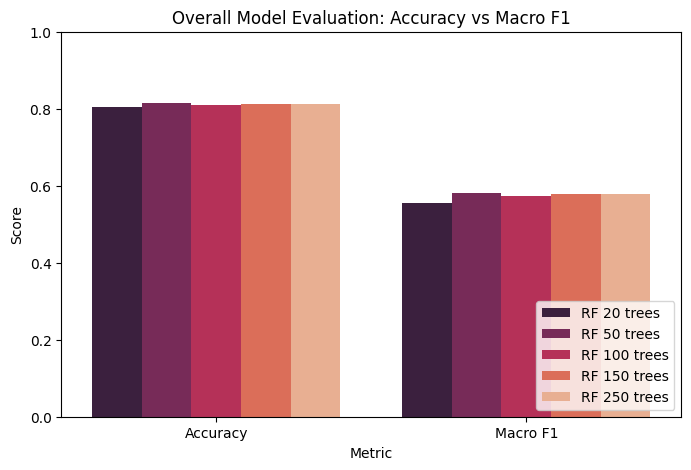

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_recall_fscore_support

# -----------------------------------------------------------
# 1. SETUP: Organize your data here
# -----------------------------------------------------------
# Assuming you have y_test and prediction arrays for each model
# Example: y_test = [0, 1, 0, ...], y_pred_lr = [0, 1, 1, ...]

# dictionary of your model names and their prediction arrays
model_preds = {
    'RF 20 trees': y_pred_r_forest_20,
    'RF 50 trees': y_pred_r_forest_50,
    'RF 100 trees': y_pred_r_forest_100,
    'RF 150 trees': y_pred_r_forest_150,
    'RF 250 trees': y_pred_r_forest_250,
}

# List of class names (optional, for better labeling)
class_names = [0, 1, 2, 3, 4, 5] 

# -----------------------------------------------------------
# 2. GRAPH: Normalized Confusion Matrices (Side-by-Side)
# -----------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(10, 10))

# Flatten axes array for easy indexing
axes = axes.flatten()

for ax, (model_name, preds) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues', cbar=False,
        xticklabels=class_names, yticklabels=class_names, ax=ax
    )

    ax.set_title(f'{model_name}\n(Normalized CM)')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

# If you have fewer models than axes, hide remaining subplots
for unused_ax in axes[len(model_preds):]:
    unused_ax.set_visible(False)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# 3. GRAPH: Per-Class Performance Comparison (Bar Chart)
# -----------------------------------------------------------
# We extract metrics for every class for every model to compare them directly
records = []
for model_name, preds in model_preds.items():
    report = classification_report(y_test, preds, output_dict=True)
    for cls in [str(c) for c in class_names]:
        # You can change 'f1-score' to 'recall' or 'precision' depending on need
        records.append({
            'Model': model_name,
            'Class': cls,
            'F1-Score': report[cls]['f1-score']
        })

df_class = pd.DataFrame(records)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_class, x='Class', y='F1-Score', hue='Model', palette='viridis')
plt.title('Comparison of F1-Score per Class across Models')
plt.grid(axis='y', alpha=0.3)
plt.show()

# -----------------------------------------------------------
# 4. GRAPH: Overall Performance (Macro vs Weighted)
# -----------------------------------------------------------
overall_data = []
for model_name, preds in model_preds.items():
    # Calculate various metrics
    acc = accuracy_score(y_test, preds)
    p, r, macro_f1, _ = precision_recall_fscore_support(y_test, preds, average='macro')
    
    overall_data.append({'Model': model_name, 'Metric': 'Accuracy', 'Score': acc})
    overall_data.append({'Model': model_name, 'Metric': 'Macro F1', 'Score': macro_f1})

df_overall = pd.DataFrame(overall_data)

plt.figure(figsize=(8, 5))
sns.barplot(data=df_overall, x='Metric', y='Score', hue='Model', palette='rocket')
plt.title('Overall Model Evaluation: Accuracy vs Macro F1')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()